In [1]:
import mod as m 
import numpy as np 
import matplotlib.pyplot as plt 

## Read in data

In [2]:
date = '04-17-26'
filename = "855Pa.txt"

arr = np.loadtxt(f"Data/HighPressureTesting-{date}/"+filename, usecols=range(1, 8))

In [3]:
ind = True 

In [4]:
x = arr[:,0]
y = arr[:,1]
z = arr[:,2]

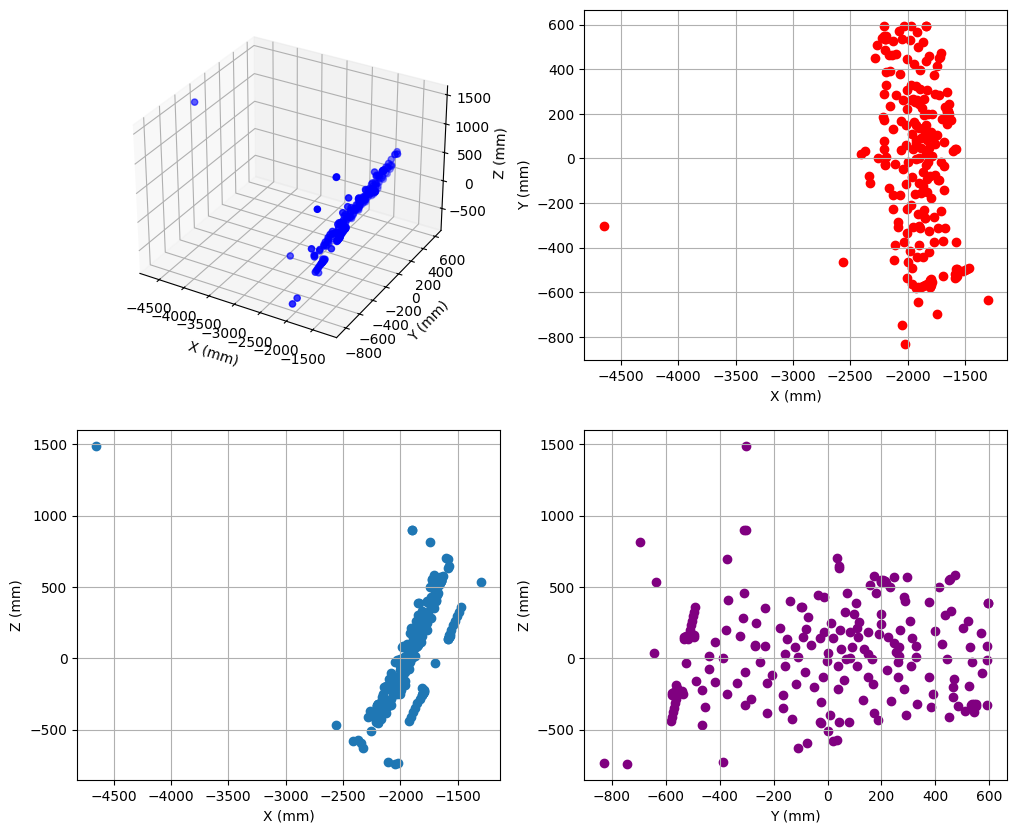

In [5]:
m.vis(x,y,z,date)

## Reference bars

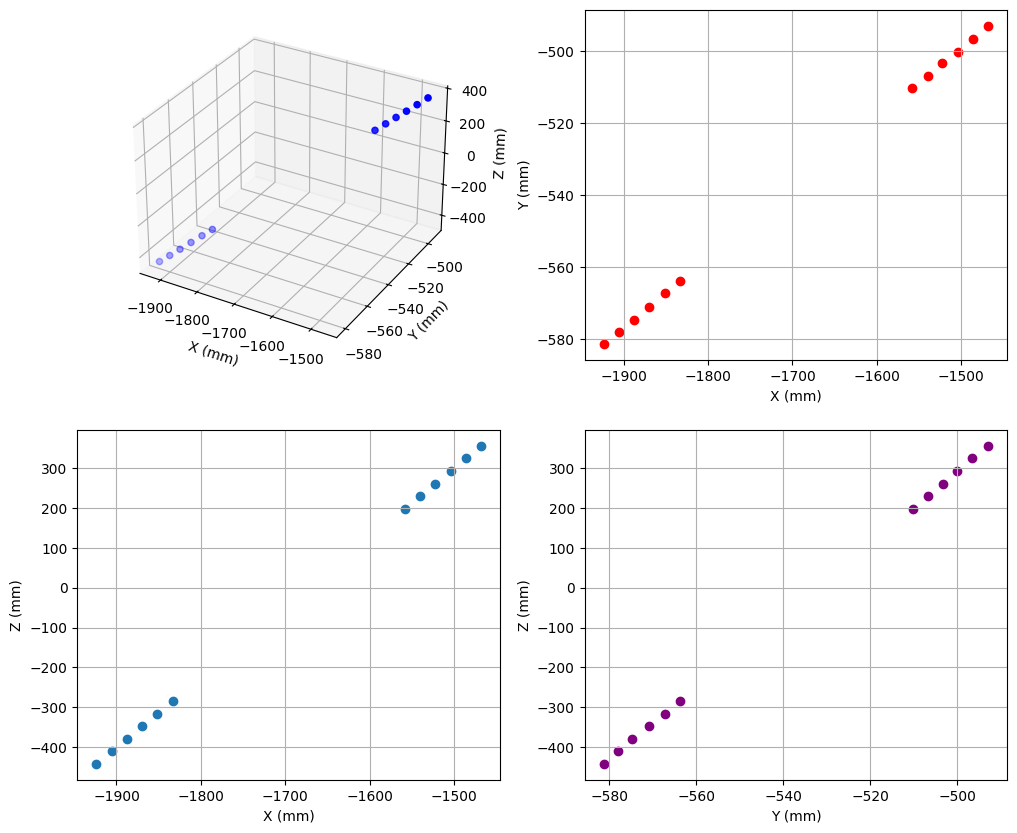

In [6]:
xb = x[4:16]
yb = y[4:16]
zb = z[4:16]

m.vis(xb, yb, zb, date)

## Crop

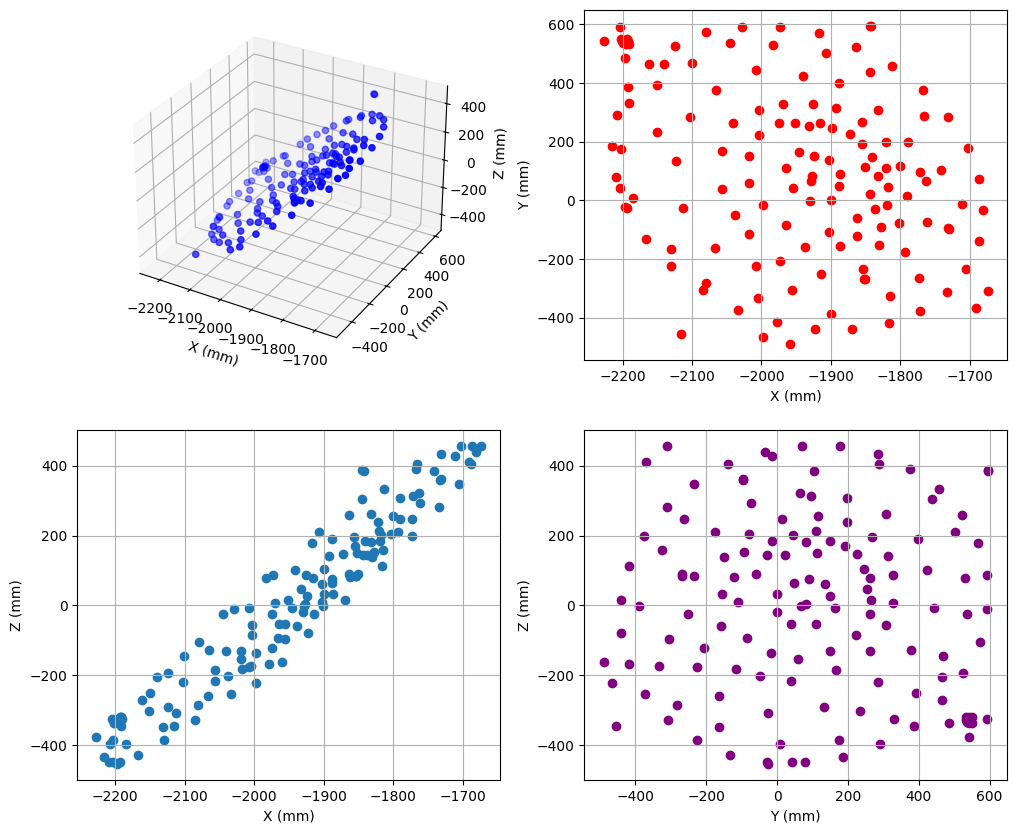

In [7]:
mask = (x > -2250) & (x < -1600) & (y > -500) & (y < 650) & (z < 500)& (z > -600) 
x, y, z = x[mask], y[mask], z[mask]
m.vis(x,y,z,date)

## Rotate based on Reference bars

In [8]:
ref = np.vstack([xb, yb, zb]).T  
pts = np.vstack([x, y, z]).T 
Xr, Yr, Zr, X, Y, Z, _, _ = m.svd_rotate(ref, pts)

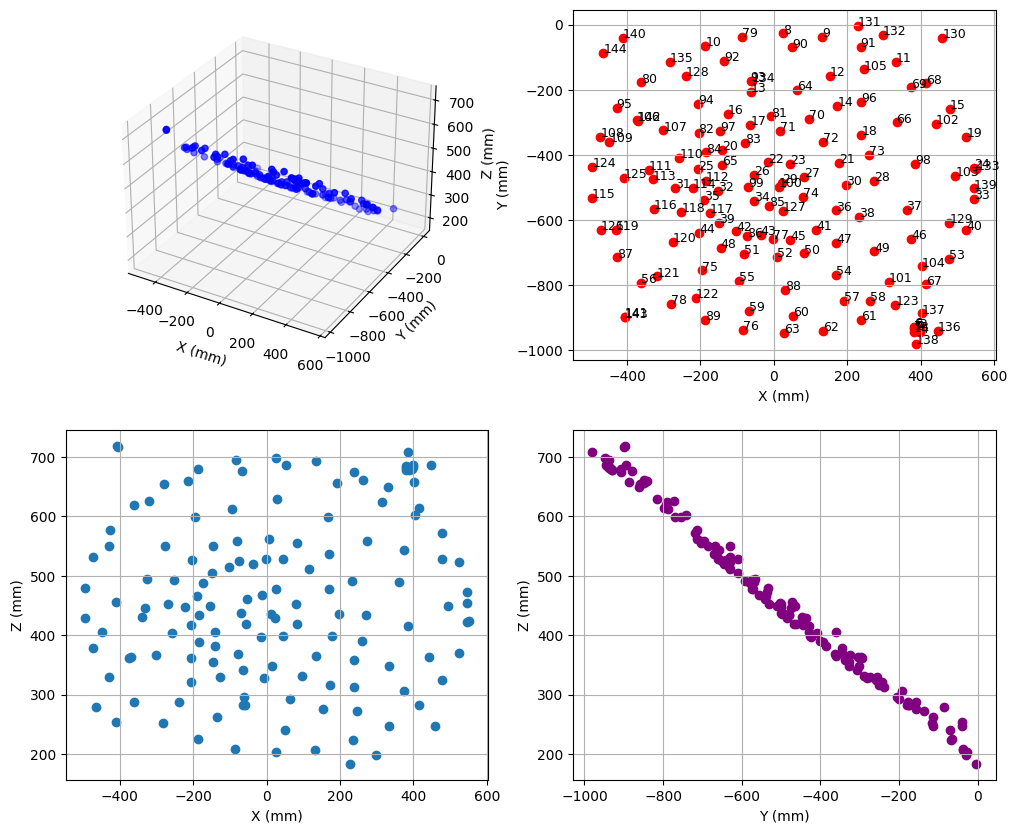

In [9]:
m.vis(X,Y,Z, date, ind=True)

## Rotate, ref -points 

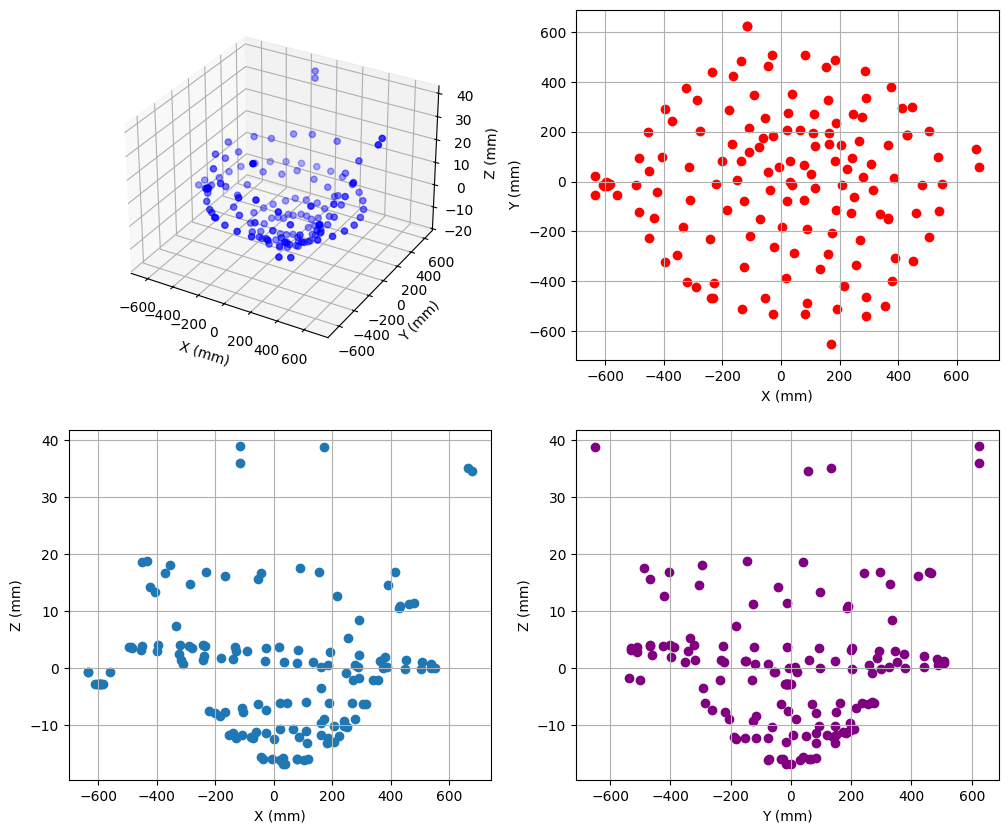

In [10]:
pts = np.vstack([x, y, z]).T 
Xr, Yr, Zr, x, y, z, _, _ = m.svd_rotate(pts, pts)
m.vis(x,y,z, date)

## Crop again

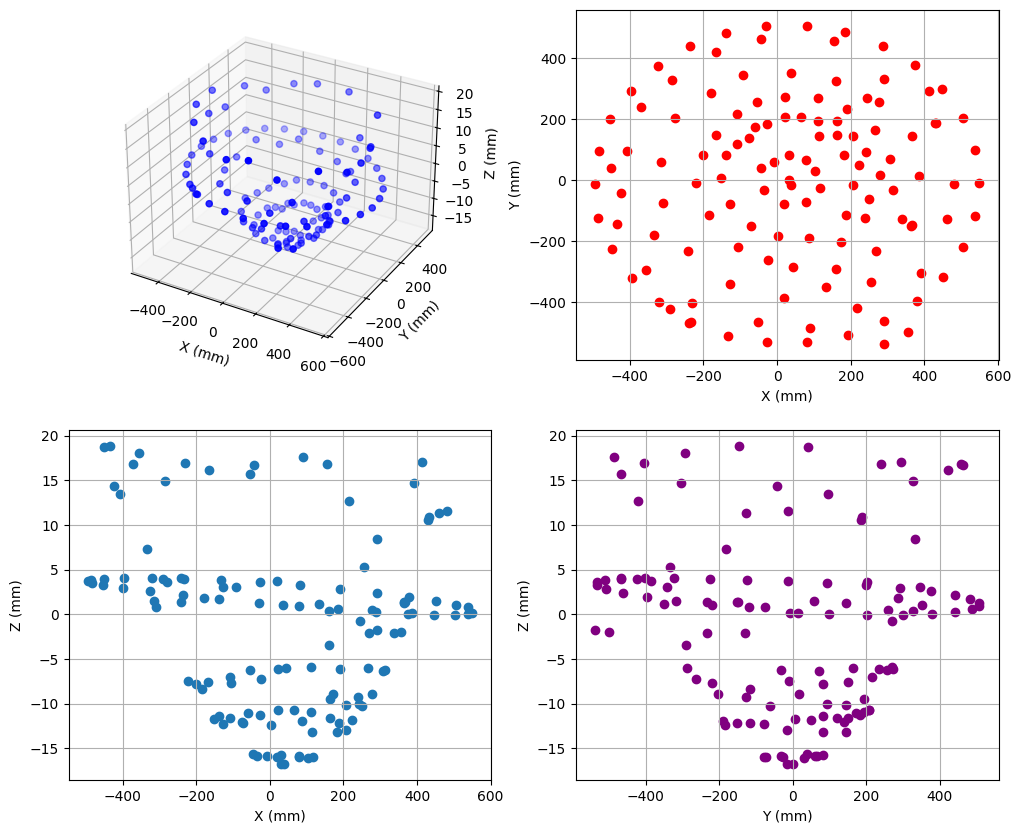

In [11]:
mask = (x > -550) & ( z < 25 )
X, Y, Z = x[mask], y[mask], z[mask]
m.vis(X,Y,Z,date)

## Rotate again

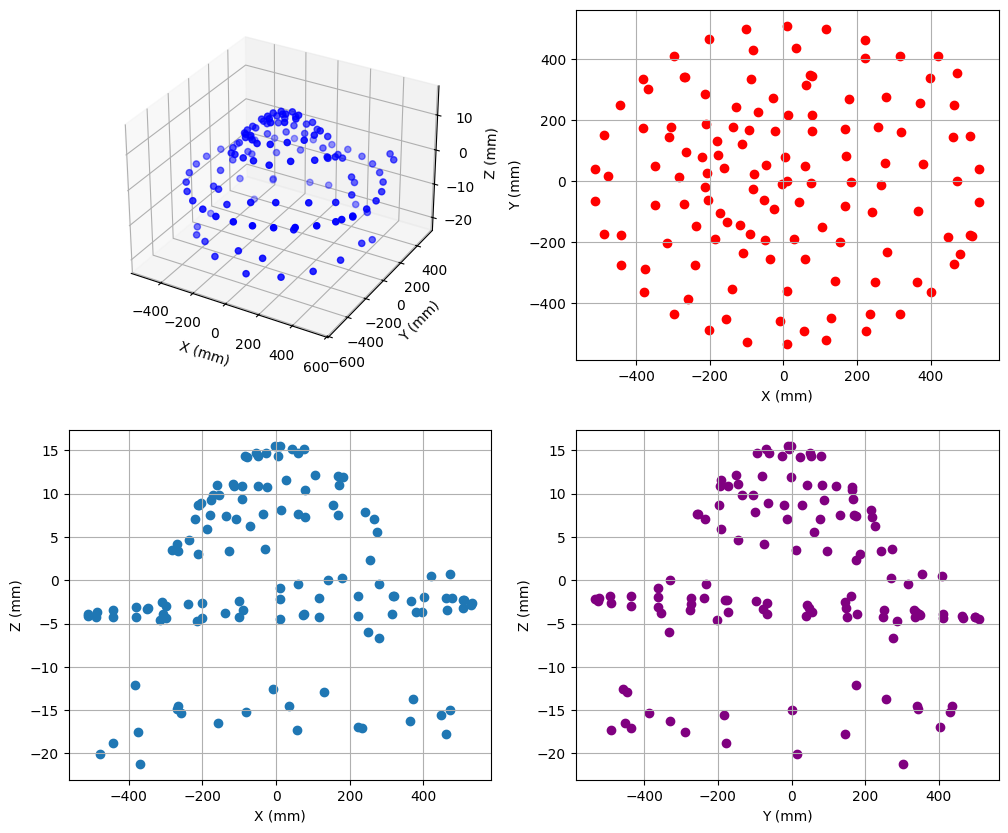

In [12]:
pts = np.vstack([X, Y, Z]).T 
Xr, Yr, Zr, X, Y, Z, _, _ = m.svd_rotate(pts, pts)
m.vis(X,Y,Z, date)

## make mask circle

In [13]:
x0, y0 = 0, 0

r = np.sqrt( (X-x0)**2 + (Y-y0)**2 ) 

rlim = 500
r_ring = 551

mask = r < rlim
mask_ring = r < r_ring

xx, yy, zz          = X[mask], Y[mask], Z[mask]
xx_r, yy_r, zz_r    = X[mask_ring], Y[mask_ring], Z[mask_ring]

In [14]:
theta = np.linspace(0,360,100)
x_c, y_c = rlim * np.cos(np.deg2rad(theta)) + x0,   rlim * np.sin(np.deg2rad(theta)) + y0
x_r, y_r = r_ring * np.cos(np.deg2rad(theta)) + x0, r_ring * np.sin(np.deg2rad(theta)) + y0

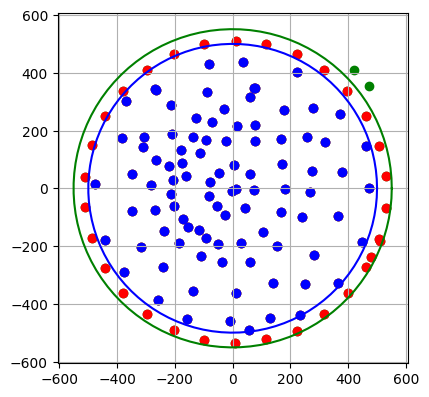

In [15]:
fig = plt.figure(figsize=(10, 10))

ax2 = fig.add_subplot(222)
ax2.scatter(X,       Y, c='green')
ax2.scatter(xx_r, yy_r, c='red')
ax2.scatter(xx,     yy, c='blue')

ax2.plot(x_c, y_c, c = 'blue')
ax2.plot(x_r, y_r, c='green')

ax2.set_aspect("equal")
ax2.grid()


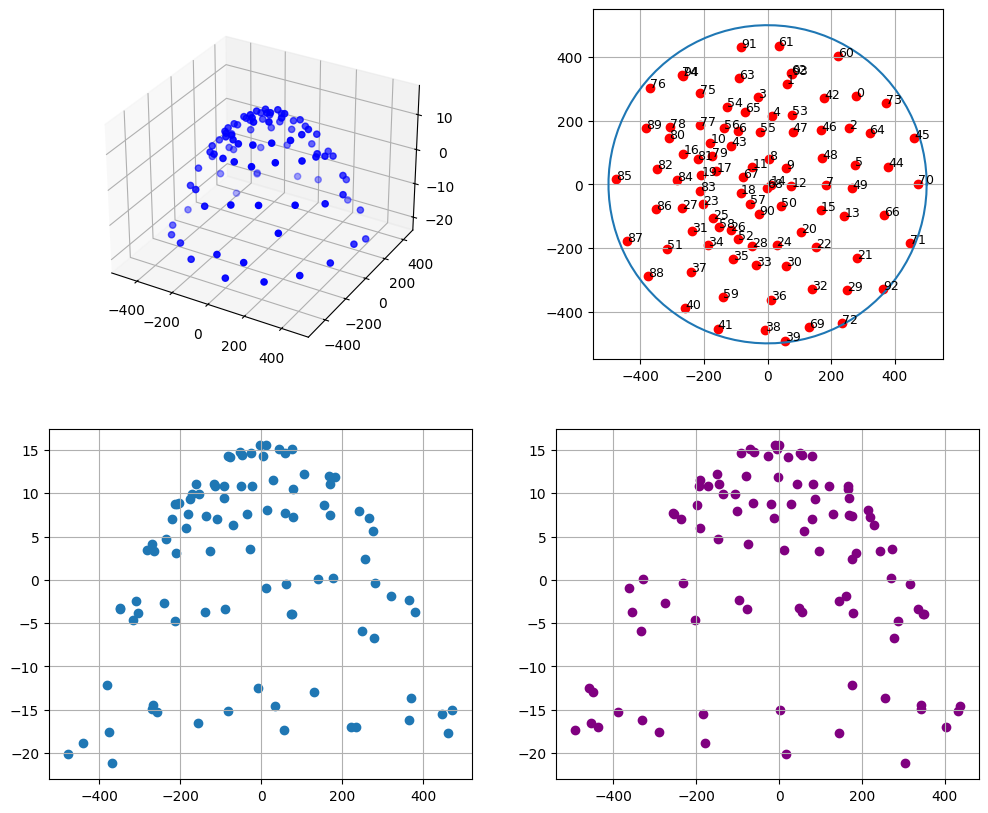

In [16]:
fig = plt.figure(figsize=(12, 10))

# 3D plot
ax1 = fig.add_subplot(221, projection='3d')
ax1.scatter(xx, yy, zz, c='blue')
# ax1.set_title('3D Plot')

# XY plane
ax2 = fig.add_subplot(222)
ax2.scatter(xx, yy, c='red')
ax2.plot(x_c, y_c)
if ind:
    for i, (xi, yi) in enumerate(zip(xx, yy)):
        ax2.text(xi, yi, str(i), fontsize=9, color='black')

ax2.set_aspect("equal")
ax2.grid()

# XZ plane
ax3 = fig.add_subplot(223)
ax3.scatter(xx, zz)
ax3.grid()

# YZ plane
ax4 = fig.add_subplot(224)
ax4.scatter(yy, zz, c='purple')
ax4.grid()

In [17]:
# write_txt_from_arrays(filename, np.append(xx, xr), np.append(yy, yr) , np.append(zz, zr))
m.write_txt_from_arrays("WithRing-"+filename, xx_r, yy_r, zz_r, date)